In [8]:
# Imports
import csv
import numpy as np

from func_magnetics import coercivity
from func_forc_analysis import compute_forc
from func_plot import plot_curves, plot_contour
from func_data_process import normalise, splitter, interpolate


In [9]:
# Importing raw data function
'''Rewrite this to fit your own data type.'''
def importer(filename):
    # Open the csv file to read
    with open(filename) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter='\t')

        # Arrays of the data
        h_data, m_data = [], []
        for row in csv_reader:
            h_data.append(row[0]), m_data.append(row[1])
    # Close the csv file.
    return h_data, m_data

In [10]:
# Field Intervals and Paths
'''Make sure to rewrite the path and intervals correctly.'''

# Creating an array of the field intervals (hr)
field_intervals = np.linspace(5000, -5000, 101, dtype=int)

# Raw data paths
path_calibration = 'sample_x_{}-calibration.txt'
path_reversal = 'sample_x_{}-reversal.txt'

In [ ]:
# Importing the data and processing

# Raw data and calibration arrays
h_data, h_cal = [], []
m_data, m_cal = [], []
coercive_data, hr_data = [], []

# For loop through the field intervals (hr)
for i in field_intervals:
    # Importing calibration and raw data
    h_calibration, m_calibration = importer((path_calibration.format(i)))
    h_reversal, m_reversal = importer((path_reversal.format(i)))

    # Calculating the coercivity of each loop
    coercivity = coercivity(m_calibration, h_calibration)

    # Calibration data
    h_cal.append(h_calibration)
    m_cal.append(m_calibration)

    # Raw reversal data
    h_data.append(h_reversal)
    m_data.append(m_reversal)

    # Coercivity and hr data
    coercive_data.append(coercivity)
    hr_data.append(np.full_like(h_reversal, i))

Data generation successful!
Loops created: 101 from limits -5000.0 to 5000.0
Coercivity of the full hysteresis (-5000 to 5000) is 965.2509652509652


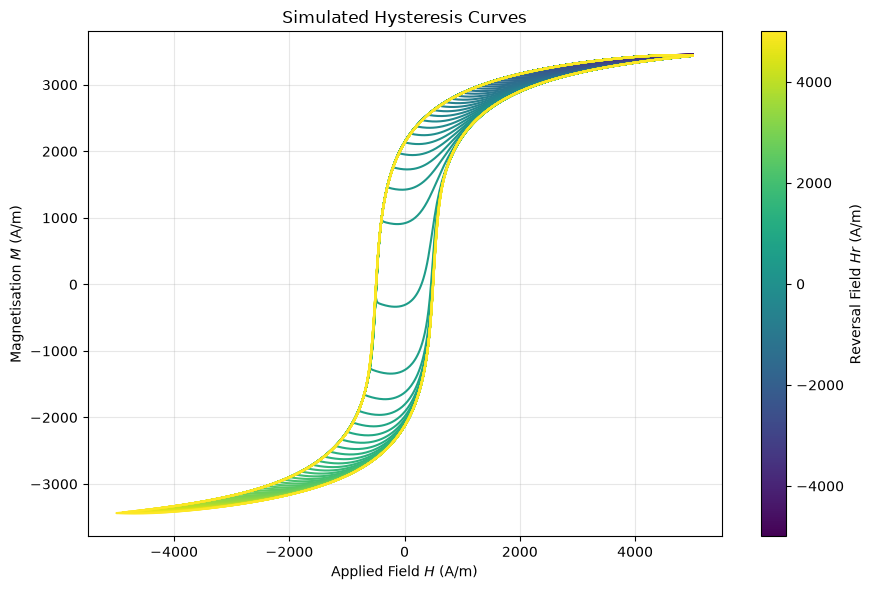

In [12]:
# Creating simulation data
'''Creating simulation data to use from this point onwards.'''
from sim_ja_model import gen_reversal_data

# Generating the reversal loops
h_data, m_data, hr_data = gen_reversal_data()
coercive = coercivity(m_data[-1], h_data[-1])

# Plotting and printing the coercivity
print('Coercivity of the full hysteresis (-5000 to 5000) is {}'.format(coercive))
plot_curves(h_data, m_data, hr_data)

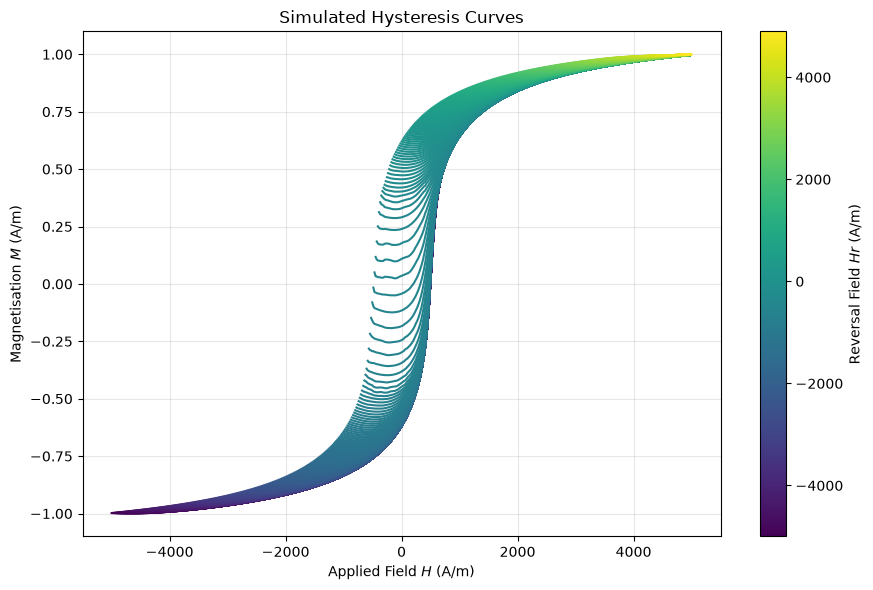

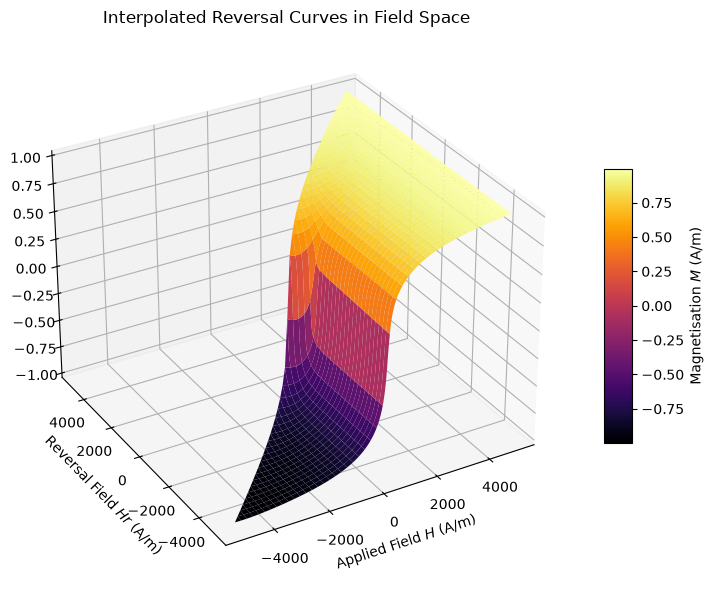

In [13]:
# Data processing

# Normalising the magnetisation between -1 and 1
h_norm, m_norm, hr_norm = normalise(h_data, m_data, hr_data)

# Splitting to only use the reversal from -h_max to h_max
h_split, m_split, hr_split = splitter(h_norm, m_norm, hr_norm)

# Interpolating the data for smoothing and creating blank space
h_int, m_int, hr_int = interpolate(h_split, m_split, hr_split)

# Plotting the interpolated data
plot_curves(h_int, m_int, hr_int)
plot_contour(h_int, hr_int, m_int, three_d=True, title='Interpolated Reversal Curves in Field Space')

Raw FORC: minimum = -1.3948363026417964e-07 and maximum = 6.106950294025634e-06
Normalised FORC: minimum = 0.0 and maximum = 1.0


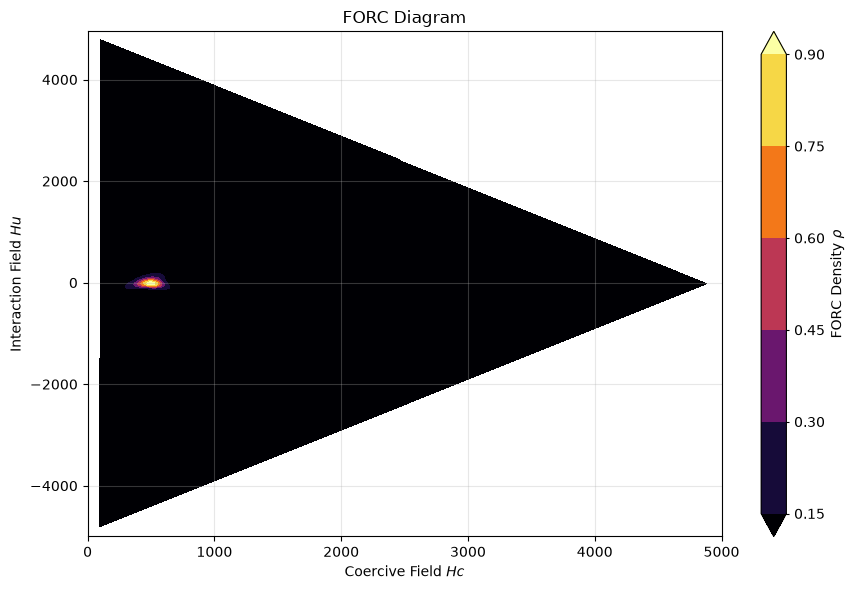

In [15]:
# Compute and plot the FORC Density
forc_data, hc_axis, hu_axis = compute_forc(h_int, m_int, hr_int, sf = 5, normalise=True)
plot_contour(hc_axis, hu_axis, forc_data, xlim=(0,5000), title='FORC Diagram', x_label='Coercive Field $Hc$', y_label='Interaction Field $Hu$', z_label='FORC Density $\\rho$')